In [1]:
#  Imports
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#  Configurations
img_size = (224, 224)
batch_size = 8
input_shape = img_size + (3,)
train_dir = r'D:\FYP\dataset_split\train'
val_dir = r'D:\FYP\dataset_split\val'
test_dir = r'D:\FYP\dataset_split\test'

In [3]:
# ==============================
# Data Generators
# ==============================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation and Test: only rescaling
val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

# ==============================
# Train Generator
# ==============================

train_ds = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# ==============================
# Validation Generator
# ==============================

val_ds = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Test Generator
# ==============================

test_ds = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

# ==============================
# Display Dataset Information
# ==============================

print("\n========== DATASET INFORMATION ==========")

print("Train images      :", train_ds.samples)
print("Validation images :", val_ds.samples)
print("Test images       :", test_ds.samples)

print("\nClass indices:")
print(train_ds.class_indices)

num_classes = train_ds.num_classes

print("\nNumber of classes :", num_classes)

Found 10500 images belonging to 3 classes.
Found 3000 images belonging to 3 classes.
Found 1500 images belonging to 3 classes.

========== DATASET INFORMATION ==========
Train images      : 10500
Validation images : 3000
Test images       : 1500

Class indices:
{'aca': 0, 'normal': 1, 'scc': 2}

Number of classes : 3


In [4]:
# Load Pretrained Model (DenseNet121)
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=input_shape
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 64s 2us/step


In [5]:
#  Compile Model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
#model.summary()

In [6]:
#  Training
early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stop, reduce_lr]
)


c:\Users\Shahzaib Rashid\miniconda3\envs\tf_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 915s 689ms/step - accuracy: 0.8348 - loss: 0.3960 - val_accuracy: 0.9487 - val_loss: 0.1335 - learning_rate: 1.0000e-04
Epoch 2/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 691s 526ms/step - accuracy: 0.9420 - loss: 0.1480 - val_accuracy: 0.9610 - val_loss: 0.1033 - learning_rate: 1.0000e-04
Epoch 3/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 588s 448ms/step - accuracy: 0.9506 - loss: 0.1261 - val_accuracy: 0.9620 - val_loss: 0.0914 - learning_rate: 1.0000e-04
Epoch 4/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 585s 446ms/step - accuracy: 0.9549 - loss: 0.1198 - val_accuracy: 0.9650 - val_loss: 0.0845 - learning_rate: 1.0000e-04
Epoch 5/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 588s 448ms/step - accuracy: 0.9588 - loss: 0.1021 - val_accuracy: 0.9713 - val_loss: 0.0700 - learning_rate: 1.0000e-04
Epoch 6/20
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 578s 440ms/step - accuracy: 0.9601 - loss: 0.0996 - val_accuracy: 0.9687 - val_loss: 0.0757 - learning_rate: 1.0000e-04
Epoch 7/20
1313/1313 ━━━━━━━

In [7]:
#  Evaluation
evaluation = model.evaluate(test_ds)
print("Evaluation results:", evaluation)

188/188 ━━━━━━━━━━━━━━━━━━━━ 121s 641ms/step - accuracy: 0.9857 - loss: 0.0354
Evaluation results: [0.043592631816864014, 0.981333315372467]


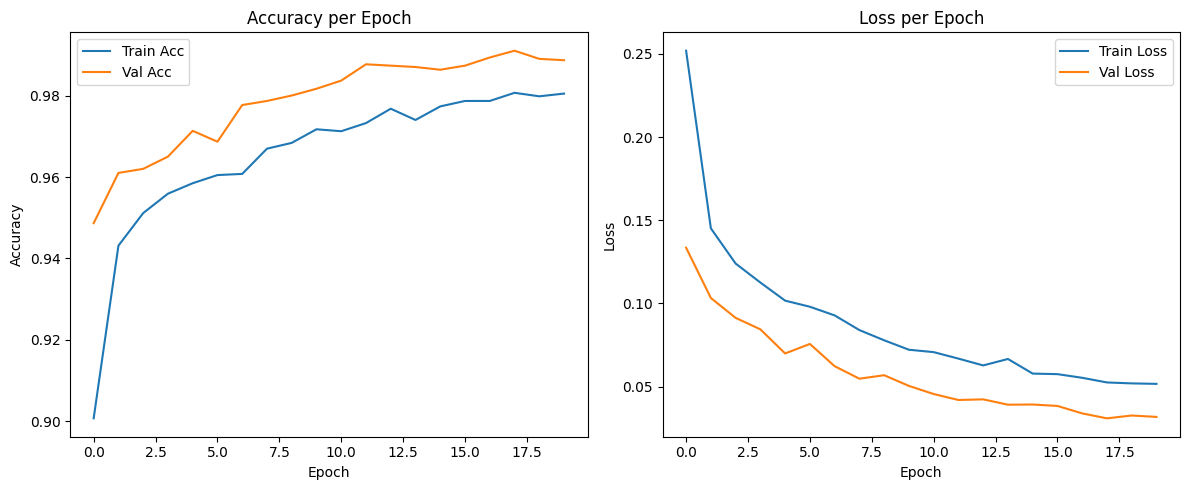

In [8]:
# Plot Accuracy & Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 120s 620ms/step


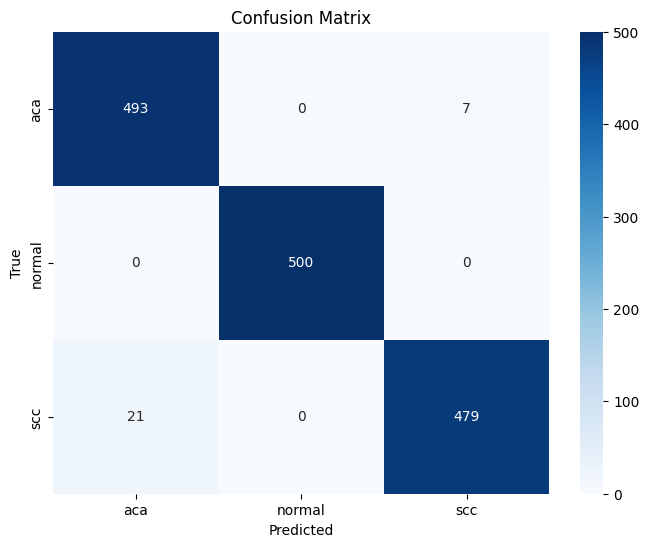

In [9]:
#  Evaluation: Confusion Matrix & All Metrics
test_ds.reset()
pred_probs = model.predict(test_ds, steps=len(test_ds), verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

# True labels
y_true = []
for i in range(len(test_ds)):
    _, labels = test_ds[i]
    y_true.extend(np.argmax(labels, axis=1))
y_true = np.array(y_true)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_names = list(test_ds.class_indices.keys())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [10]:
# Metrics: Accuracy, Precision, Recall, F1
acc = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Accuracy:  0.9813
Precision: 0.9816
Recall:    0.9813
F1-Score:  0.9813


In [11]:
#  Detailed Report
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

Classification Report:
              precision    recall  f1-score   support

         aca       0.96      0.99      0.97       500
      normal       1.00      1.00      1.00       500
         scc       0.99      0.96      0.97       500

    accuracy                           0.98      1500
   macro avg       0.98      0.98      0.98      1500
weighted avg       0.98      0.98      0.98      1500



In [12]:
model.save('DenseNet121.keras')